In [1]:
import pandas as pd
import numpy as np
import os
import re
import string
import matplotlib.pyplot as plt
import shap
import scipy.stats as stats

# Sklearn & Models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
CONFIG = {
    "PATH_ECON": "structured_data",
    "FILE_MINUTES": "FOMC_Minutes_1999_2025.csv",
    "FILE_DICT": "Loughran-McDonald_MasterDictionary_1993-2024.csv",
    "DATE_START": "1999-02-01",
    "DATE_END": "2025-01-01",
    "RANDOM_SEED": 42
}

# ==============================================================================
# 2. MODEL WRAPPERS
# ==============================================================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps classifiers to ensure predict_proba ALWAYS returns 3 columns [Cut, Hold, Raise],
    even if the training fold is missing a class (e.g., no rate cuts in a specific year).
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        # Fit LabelEncoder to map current y to 0..N-1
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        # Create full matrix (N_samples, 3) initialized with zeros
        probs_full = np.zeros((len(X), 3))
        
        # Map existing probabilities to the correct columns (0, 1, 2)
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

class AgentModel(BaseEstimator, ClassifierMixin):
    """
    Stacking Ensemble (The 'Agent' Model).
    Consists of 3 'Specialist' models feeding predictions to a 'Decision' meta-learner.
    """
    def __init__(self):
        self.specialists = {
            'Logistic': SafeModelWrapper(LogisticRegression(max_iter=3000, class_weight='balanced', C=0.5)),
            'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=CONFIG['RANDOM_SEED'])),
            'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED']))
        }
        self.decision_agent = LogisticRegression(class_weight='balanced', max_iter=3000)
        
    def fit(self, X, y):
        # 1. Train Specialists
        for model in self.specialists.values():
            model.fit(X, y)
            
        # 2. Generate Specialist Opinions (Meta-Features)
        meta_features = self._get_meta_features(X)
            
        # 3. Train Decision Agent
        self.decision_agent.fit(meta_features, y)
        return self
    
    def predict(self, X):
        return self.decision_agent.predict(self._get_meta_features(X))
    
    def predict_proba(self, X):
        return self.decision_agent.predict_proba(self._get_meta_features(X))

    def _get_meta_features(self, X):
        # Generate prediction probabilities from all specialists
        meta = pd.DataFrame(index=range(len(X)))
        for name, model in self.specialists.items():
            probs = model.predict_proba(X)
            meta[f'{name}_Cut'] = probs[:, 0]
            meta[f'{name}_Hold'] = probs[:, 1]
            meta[f'{name}_Raise'] = probs[:, 2]
        return meta

# ==============================================================================
# 3. DATA PROCESSING PIPELINE
# ==============================================================================
def load_and_process_data():
    print(">> [Data] Loading and processing...")
    
    # --- 1. Load Economic Data & Engineer Trends ---
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12), 'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12), 'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1), 'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(CONFIG['PATH_ECON'], fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean() # 3-Month Trend
            
            # Feature: Raw Difference (Baseline)
            feat = s.pct_change(lag) * 100 if key in ['CPI', 'PCE'] else s.diff(lag)
            feat.name = f'{key}_raw'
            
            # Feature: Trend Difference (Enhanced)
            trend = roll.pct_change(lag) * 100 if key in ['CPI', 'PCE'] else roll.diff(lag)
            trend.name = f'{key}_trend_3m'
            
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    
    # --- 2. Load Text Data & TF-IDF ---
    df_txt = pd.read_csv(CONFIG['FILE_MINUTES'])
    # Extract date from Link
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', str(t).lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    # Unigrams (Baseline)
    tfidf_uni = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 1))
    uni_mat = tfidf_uni.fit_transform(df_txt['clean'])
    df_uni = pd.DataFrame(uni_mat.toarray(), columns=[f"uni_{w}" for w in tfidf_uni.get_feature_names_out()], index=df_txt.index)
    
    # Bi-grams (Enhanced)
    tfidf_bi = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    bi_mat = tfidf_bi.fit_transform(df_txt['clean'])
    df_bi = pd.DataFrame(bi_mat.toarray(), columns=[f"bi_{w}" for w in tfidf_bi.get_feature_names_out()], index=df_txt.index)
    
    df_txt_all = pd.concat([df_uni, df_bi], axis=1)
    df_txt_all.index = df_txt_all.index.to_period('M').to_timestamp()
    
    # --- 3. Merge & Create Target ---
    df_merged = pd.merge(df_econ, df_txt_all, left_index=True, right_index=True, how='inner')
    
    ff = pd.read_csv(os.path.join(CONFIG['PATH_ECON'], 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    
    # Target: Next Month's Change
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    # Class Mapping: 0=Cut (< -0.125), 1=Hold, 2=Raise (> 0.125)
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    return df_merged.loc[CONFIG['DATE_START'] : CONFIG['DATE_END']]

# ==============================================================================
# 4. COMPARATIVE ANALYSIS ENGINE
# ==============================================================================
def run_comparison(df):
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    
    # Define Feature Sets
    cols_base = [c for c in X.columns if 'raw' in c or 'uni_' in c] # Baseline Features
    cols_enh  = [c for c in X.columns if 'raw' in c or 'trend' in c or 'bi_' in c] # Enhanced Features
    
    # Define Models to Compare
    # Format: 'Name': (ModelInstance, FeatureColumns)
    models = {
        'Baseline': (SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=4, random_state=CONFIG['RANDOM_SEED'])), cols_base),
        'Enhanced': (SafeModelWrapper(XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED'])), cols_enh),
        'Agent':    (AgentModel(), cols_enh)
    }
    
    results = {m: {'auc_scores': [], 'acc_scores': [], 'cut_recalls': []} for m in models}
    
    # --- 1. Stratified K-Fold CV (For Statistical Significance) ---
    print("\n>> Running Stratified 5-Fold CV...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_SEED'])
    scaler = StandardScaler()
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"   - Processing Fold {fold + 1}/5...")
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        for name, (model, cols) in models.items():
            # Scale
            scaler.fit(X_train_fold[cols])
            Xt_tr = pd.DataFrame(scaler.transform(X_train_fold[cols]), index=X_train_fold.index, columns=cols)
            Xt_te = pd.DataFrame(scaler.transform(X_test_fold[cols]), index=X_test_fold.index, columns=cols)
            
            # SMOTE (Handle Imbalance in Training)
            try:
                min_class_samples = y_train_fold.value_counts().min()
                k_neighbors = min(min_class_samples - 1, 5)
                if k_neighbors > 0:
                    sm = SMOTE(random_state=CONFIG['RANDOM_SEED'], k_neighbors=k_neighbors)
                    X_res, y_res = sm.fit_resample(Xt_tr, y_train_fold)
                else:
                    X_res, y_res = Xt_tr, y_train_fold
            except:
                X_res, y_res = Xt_tr, y_train_fold
                
            # Train & Predict
            model.fit(X_res, y_res)
            preds = model.predict(Xt_te)
            probs = model.predict_proba(Xt_te)
            
            # Store Metrics
            if len(np.unique(y_test_fold)) > 1:
                try:
                    auc = roc_auc_score(y_test_fold, probs, multi_class='ovr')
                    results[name]['auc_scores'].append(auc)
                except: pass
            results[name]['acc_scores'].append(accuracy_score(y_test_fold, preds))
            results[name]['cut_recalls'].append(recall_score(y_test_fold, preds, labels=[0], average='macro'))

    return results

# ==============================================================================
# 5. EXECUTION & REPORTING
# ==============================================================================
def print_report(results):
    print("\n" + "="*60)
    print(f"FINAL COMPARATIVE REPORT")
    print("="*60)
    
    # 1. Performance Table
    print(f"{'Model':<12} | {'AUC (Mean)':<12} | {'AUC (Std)':<12} | {'Recall (Cuts)':<15}")
    print("-" * 60)
    
    for name in results:
        auc_mu = np.mean(results[name]['auc_scores'])
        auc_std = np.std(results[name]['auc_scores'])
        rec = np.mean(results[name]['cut_recalls'])
        print(f"{name:<12} | {auc_mu:.4f}       | {auc_std:.4f}       | {rec:.2%}")
        
    # 2. Statistical Significance (Agent vs Baseline)
    print("\n[Statistical Significance Test]")
    scores_agent = results['Agent']['auc_scores']
    scores_base = results['Baseline']['auc_scores']
    
    if len(scores_agent) > 1 and len(scores_base) > 1:
        t_stat, p_val = stats.ttest_rel(scores_agent, scores_base)
        sig = "**SIGNIFICANT**" if p_val < 0.05 else "Not Significant"
        print(f"Agent vs Baseline (Paired t-test): p-value = {p_val:.4f} ({sig})")
    else:
        print("Insufficient data for t-test.")

if __name__ == "__main__":
    try:
        # 1. Load Data
        df_final = load_and_process_data()
        print(f">> Data Loaded. Shape: {df_final.shape}")
        
        # 2. Run Comparison
        results_dict = run_comparison(df_final)
        
        # 3. Print Report
        print_report(results_dict)
        
    except Exception as e:
        import traceback
        print(f"\nERROR: {e}")
        print("Please ensure your CSV files are in the 'structured_data' folder.")
        traceback.print_exc()

c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>> [Data] Loading and processing...
>> Data Loaded. Shape: (204, 616)

>> Running Stratified 5-Fold CV...
   - Processing Fold 1/5...
   - Processing Fold 2/5...
   - Processing Fold 3/5...
   - Processing Fold 4/5...
   - Processing Fold 5/5...

FINAL COMPARATIVE REPORT
Model        | AUC (Mean)   | AUC (Std)    | Recall (Cuts)  
------------------------------------------------------------
Baseline     | 0.9358       | 0.0396       | 86.00%
Enhanced     | 0.9349       | 0.0372       | 86.00%
Agent        | 0.9252       | 0.0409       | 82.67%

[Statistical Significance Test]
Agent vs Baseline (Paired t-test): p-value = 0.1070 (Not Significant)


In [1]:
import pandas as pd
import numpy as np
import os
import re
import string
import matplotlib.pyplot as plt
import scipy.stats as stats

# Sklearn & Models
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, KFold
from imblearn.over_sampling import SMOTE

# ==============================================================================
# 1. CONFIGURATION
# ==============================================================================
CONFIG = {
    "PATH_ECON": "structured_data",
    "FILE_MINUTES": "FOMC_Minutes_1999_2025.csv",
    "FILE_DICT": "Loughran-McDonald_MasterDictionary_1993-2024.csv",
    "DATE_START": "2011-01-01",  # <-- UPDATED START DATE
    "DATE_END": "2025-01-01",    # <-- UPDATED END DATE
    "RANDOM_SEED": 42
}

# ==============================================================================
# 2. MODEL WRAPPERS
# ==============================================================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps classifiers to ensure predict_proba ALWAYS returns 3 columns [Cut, Hold, Raise],
    even if the training fold is missing a class.
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        probs_full = np.zeros((len(X), 3))
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

class AgentModel(BaseEstimator, ClassifierMixin):
    """
    Stacking Ensemble (The 'Agent' Model).
    """
    def __init__(self):
        self.specialists = {
            'Logistic': SafeModelWrapper(LogisticRegression(max_iter=3000, class_weight='balanced', C=0.5)),
            'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=CONFIG['RANDOM_SEED'])),
            'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED']))
        }
        self.decision_agent = LogisticRegression(class_weight='balanced', max_iter=3000)
        
    def fit(self, X, y):
        for model in self.specialists.values():
            model.fit(X, y)
        meta_features = self._get_meta_features(X)
        self.decision_agent.fit(meta_features, y)
        return self
    
    def predict(self, X):
        return self.decision_agent.predict(self._get_meta_features(X))
    
    def predict_proba(self, X):
        return self.decision_agent.predict_proba(self._get_meta_features(X))

    def _get_meta_features(self, X):
        meta = pd.DataFrame(index=range(len(X)))
        for name, model in self.specialists.items():
            probs = model.predict_proba(X)
            meta[f'{name}_Cut'] = probs[:, 0]
            meta[f'{name}_Hold'] = probs[:, 1]
            meta[f'{name}_Raise'] = probs[:, 2]
        return meta

# ==============================================================================
# 3. DATA PROCESSING PIPELINE
# ==============================================================================
def load_and_process_data():
    print(f">> [Data] Loading and processing for period: {CONFIG['DATE_START']} to {CONFIG['DATE_END']}...")
    
    # --- 1. Load Economic Data & Engineer Trends ---
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12), 'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12), 'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1), 'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(CONFIG['PATH_ECON'], fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean() # 3-Month Trend
            
            feat = s.pct_change(lag) * 100 if key in ['CPI', 'PCE'] else s.diff(lag)
            feat.name = f'{key}_raw'
            
            trend = roll.pct_change(lag) * 100 if key in ['CPI', 'PCE'] else roll.diff(lag)
            trend.name = f'{key}_trend_3m'
            
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    
    # --- 2. Load Text Data & TF-IDF ---
    df_txt = pd.read_csv(CONFIG['FILE_MINUTES'])
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', str(t).lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    # Unigrams (Baseline)
    tfidf_uni = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 1))
    uni_mat = tfidf_uni.fit_transform(df_txt['clean'])
    df_uni = pd.DataFrame(uni_mat.toarray(), columns=[f"uni_{w}" for w in tfidf_uni.get_feature_names_out()], index=df_txt.index)
    
    # Bi-grams (Enhanced)
    tfidf_bi = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    bi_mat = tfidf_bi.fit_transform(df_txt['clean'])
    df_bi = pd.DataFrame(bi_mat.toarray(), columns=[f"bi_{w}" for w in tfidf_bi.get_feature_names_out()], index=df_txt.index)
    
    df_txt_all = pd.concat([df_uni, df_bi], axis=1)
    df_txt_all.index = df_txt_all.index.to_period('M').to_timestamp()
    
    # --- 3. Merge & Create Target ---
    df_merged = pd.merge(df_econ, df_txt_all, left_index=True, right_index=True, how='inner')
    
    ff = pd.read_csv(os.path.join(CONFIG['PATH_ECON'], 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    
    # Target: Next Month's Change
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    # Class Mapping: 0=Cut (< -0.125), 1=Hold, 2=Raise (> 0.125)
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    # Filter for Specific Date Range
    return df_merged.loc[CONFIG['DATE_START'] : CONFIG['DATE_END']]

# ==============================================================================
# 4. COMPARATIVE ANALYSIS ENGINE
# ==============================================================================
def run_comparison(df):
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    
    # Feature Sets
    cols_base = [c for c in X.columns if 'raw' in c or 'uni_' in c]
    cols_enh  = [c for c in X.columns if 'raw' in c or 'trend' in c or 'bi_' in c]
    
    models = {
        'Baseline': (SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=4, random_state=CONFIG['RANDOM_SEED'])), cols_base),
        'Enhanced': (SafeModelWrapper(XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=CONFIG['RANDOM_SEED'])), cols_enh),
        'Agent':    (AgentModel(), cols_enh)
    }
    
    results = {m: {'auc_scores': [], 'cut_recalls': []} for m in models}
    
    # --- Check Class Distribution for CV Strategy ---
    class_counts = y.value_counts()
    min_class_samples = class_counts.min()
    print(f"\n>> Class Distribution: {class_counts.to_dict()}")
    
    # If a class is too rare (<5 samples), switch to standard KFold to avoid errors
    if min_class_samples < 5:
        print("   WARNING: Rare class detected. Switching to standard K-Fold CV.")
        cv = KFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_SEED'])
    else:
        print("   Using Stratified K-Fold CV.")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=CONFIG['RANDOM_SEED'])
    
    scaler = StandardScaler()
    
    print("\n>> Running Cross-Validation...")
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        for name, (model, cols) in models.items():
            # Scale
            scaler.fit(X_train_fold[cols])
            Xt_tr = pd.DataFrame(scaler.transform(X_train_fold[cols]), index=X_train_fold.index, columns=cols)
            Xt_te = pd.DataFrame(scaler.transform(X_test_fold[cols]), index=X_test_fold.index, columns=cols)
            
            # SMOTE (Adaptive k_neighbors)
            try:
                min_samples = y_train_fold.value_counts().min()
                k = min(min_samples - 1, 5)
                if k > 0:
                    sm = SMOTE(random_state=CONFIG['RANDOM_SEED'], k_neighbors=k)
                    X_res, y_res = sm.fit_resample(Xt_tr, y_train_fold)
                else:
                    X_res, y_res = Xt_tr, y_train_fold
            except:
                X_res, y_res = Xt_tr, y_train_fold
                
            # Train & Predict
            model.fit(X_res, y_res)
            probs = model.predict_proba(Xt_te)
            preds = model.predict(Xt_te)
            
            # Metrics
            if len(np.unique(y_test_fold)) > 1:
                try:
                    auc = roc_auc_score(y_test_fold, probs, multi_class='ovr')
                    results[name]['auc_scores'].append(auc)
                except: pass
            
            # Recall for Cuts (Class 0)
            rec = recall_score(y_test_fold, preds, labels=[0], average='macro', zero_division=0)
            results[name]['cut_recalls'].append(rec)

    return results

# ==============================================================================
# 5. EXECUTION & REPORTING
# ==============================================================================
def print_report(results):
    print("\n" + "="*60)
    print(f"FINAL COMPARATIVE REPORT ({CONFIG['DATE_START']} - {CONFIG['DATE_END']})")
    print("="*60)
    
    print(f"{'Model':<12} | {'AUC (Mean)':<12} | {'AUC (Std)':<12} | {'Recall (Cuts)':<15}")
    print("-" * 60)
    
    for name in results:
        auc_mu = np.mean(results[name]['auc_scores'])
        auc_std = np.std(results[name]['auc_scores'])
        rec = np.mean(results[name]['cut_recalls'])
        print(f"{name:<12} | {auc_mu:.4f}       | {auc_std:.4f}       | {rec:.2%}")
        
    print("\n[Statistical Significance Test]")
    scores_agent = results['Agent']['auc_scores']
    scores_base = results['Baseline']['auc_scores']
    
    if len(scores_agent) > 1 and len(scores_base) > 1:
        t_stat, p_val = stats.ttest_rel(scores_agent, scores_base)
        sig = "**SIGNIFICANT**" if p_val < 0.05 else "Not Significant"
        print(f"Agent vs Baseline (Paired t-test): p-value = {p_val:.4f} ({sig})")
    else:
        print("Insufficient data for t-test.")

if __name__ == "__main__":
    try:
        df_final = load_and_process_data()
        print(f">> Data Loaded. Shape: {df_final.shape}")
        
        if df_final.empty:
            print("ERROR: No data found for the specified date range.")
        else:
            results_dict = run_comparison(df_final)
            print_report(results_dict)
        
    except Exception as e:
        import traceback
        print(f"\nERROR: {e}")
        traceback.print_exc()

>> [Data] Loading and processing for period: 2011-01-01 to 2025-01-01...
>> Data Loaded. Shape: (113, 616)

>> Class Distribution: {1: 90, 2: 16, 0: 7}
   Using Stratified K-Fold CV.

>> Running Cross-Validation...

FINAL COMPARATIVE REPORT (2011-01-01 - 2025-01-01)
Model        | AUC (Mean)   | AUC (Std)    | Recall (Cuts)  
------------------------------------------------------------
Baseline     | 0.9088       | 0.0790       | 60.00%
Enhanced     | 0.9058       | 0.0780       | 80.00%
Agent        | 0.9260       | 0.0571       | 70.00%

[Statistical Significance Test]
Agent vs Baseline (Paired t-test): p-value = 0.4478 (Not Significant)


>> Training Enhanced Model for SHAP analysis on 314 features...
>> Calculating SHAP values...
>> Detected SHAP format: 3D Array (Newer XGBoost/SHAP)
   Shape of Class 0 SHAP values: (113, 314)
   Number of features: 314

>> TOP 15 BIGRAMS DRIVING 'RATE CUT' PREDICTIONS:
                 Feature  Importance
216             bi_point    0.450794
142          bi_increase    0.180747
119           bi_foreign    0.023142
16             bi_action    0.022847
93          bi_equipment    0.022602
199          bi_november    0.013995
280            bi_stance    0.010842
218            bi_policy    0.009524
126            bi_future    0.008891
187  bi_monetary affairs    0.008647
284          bi_strength    0.008475
296             bi_trade    0.008068
21              bi_ahead    0.007998
17           bi_activity    0.007002
182           bi_members    0.006889


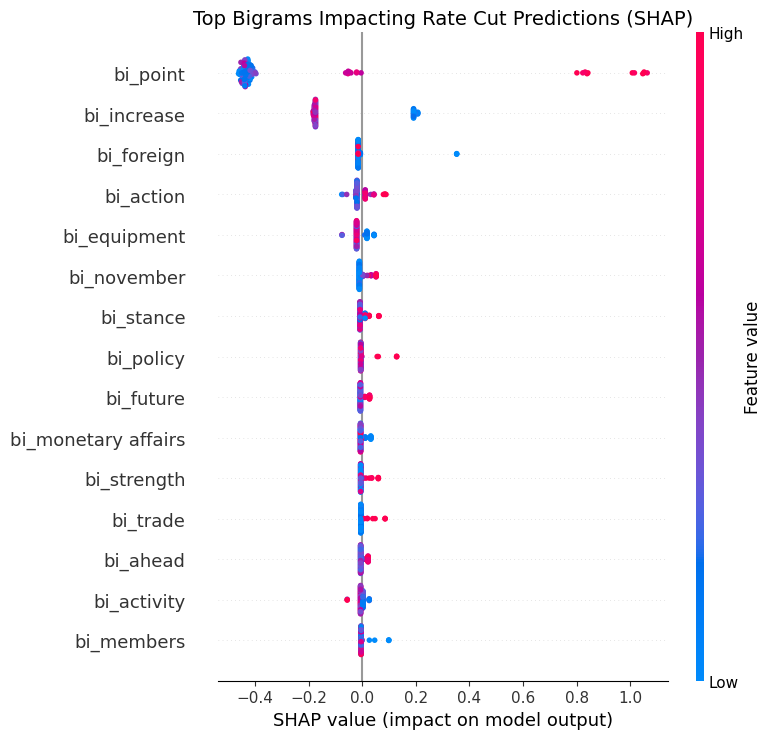

In [3]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

# ==============================================================================
# ROBUST SHAP ANALYSIS FOR "ENHANCED" MODEL (Recall on Rate Cuts)
# ==============================================================================

# 1. Setup Data & Features
# ------------------------------------------------------------------------------
# Ensure df_final is loaded. If not, run: df_final = load_and_process_data()

X = df_final.drop(columns=['Target', 'Next_Change'])
y = df_final['Target']

# Define "Enhanced" Feature Set (Trends + Bigrams + Raw)
cols_enh = [c for c in X.columns if 'raw' in c or 'trend' in c or 'bi_' in c]
X_enh = X[cols_enh]

print(f">> Training Enhanced Model for SHAP analysis on {X_enh.shape[1]} features...")

# 2. Train the Enhanced Model
# ------------------------------------------------------------------------------
model_enh = XGBClassifier(
    n_estimators=200, 
    max_depth=5, 
    learning_rate=0.05, 
    random_state=42
)
model_enh.fit(X_enh, y)

# 3. Compute SHAP Values
# ------------------------------------------------------------------------------
print(">> Calculating SHAP values...")
explainer = shap.TreeExplainer(model_enh)
shap_values = explainer.shap_values(X_enh)

# --- ROBUST EXTRACTION LOGIC ---
# Handle different SHAP output formats (List vs 3D Array)
if isinstance(shap_values, list):
    print(">> Detected SHAP format: List (Standard)")
    # List of [Class0, Class1, Class2] -> Take index 0 for Cuts
    shap_values_cut = shap_values[0]
elif hasattr(shap_values, 'ndim') and shap_values.ndim == 3:
    print(">> Detected SHAP format: 3D Array (Newer XGBoost/SHAP)")
    # Array of (Samples, Features, Classes) -> Slice [:, :, 0] for Cuts
    shap_values_cut = shap_values[:, :, 0]
else:
    print(">> Detected SHAP format: 2D Array (Binary/Single)")
    # Likely binary or single output
    shap_values_cut = shap_values

# Verify shapes
print(f"   Shape of Class 0 SHAP values: {shap_values_cut.shape}")
print(f"   Number of features: {len(X_enh.columns)}")

if shap_values_cut.shape[1] != len(X_enh.columns):
    raise ValueError(f"Shape mismatch! SHAP features ({shap_values_cut.shape[1]}) != Data columns ({len(X_enh.columns)})")

# 4. Filter & Visualize Top Bigrams for "Cuts"
# ------------------------------------------------------------------------------
mean_shap = np.abs(shap_values_cut).mean(axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_enh.columns,
    'Importance': mean_shap
}).sort_values(by='Importance', ascending=False)

# Extract only Bigrams
top_bigrams = feature_importance[feature_importance['Feature'].str.startswith('bi_')].head(15)

print("\n>> TOP 15 BIGRAMS DRIVING 'RATE CUT' PREDICTIONS:")
print(top_bigrams)

# 5. Plotting
# ------------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.title("Top Bigrams Impacting Rate Cut Predictions (SHAP)", fontsize=14)

# Get indices of top bigrams to slice the SHAP matrix
bigram_indices = [X_enh.columns.get_loc(c) for c in top_bigrams['Feature']]

shap.summary_plot(
    shap_values_cut[:, bigram_indices], 
    X_enh.iloc[:, bigram_indices],
    feature_names=top_bigrams['Feature'].tolist(),
    show=True
)